In [10]:
import sys
from pathlib import Path
import torch

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
import Python.simfun as sim


X1, y1, beta1, sim_info1 = sim.simfun1(
    sim="simple",
    n=160,
    p=100,
    seed=400,
    n_active=10,
    sigma2=1,
    device=device,
    dtype=torch.float32,
)


X2, y2, beta2, sim_info2 = sim.simfun1(
    sim="simple",
    n=100,
    p=500,
    seed=400,
    n_active=10,
    sigma2=1,
    device=device,
    dtype=torch.float32,
)


In [14]:
%load_ext autoreload
%autoreload 2

import Python.config as cfg
import Python.framework as fw
import Python.model as md


split_cfg = cfg.SplitConfig(
    train_frac=0.6,
    val_frac=0.2,
    test_frac=0.2,
    seed=123,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
schedule_cfg_test = cfg.StagewiseAnnealConfig(
    tau_start=0.8,
    tau_end=0.8,
    warmup_epochs=100,
    n_anneal_stages=1,
    min_stage_epochs=1000,
    max_stage_epochs=1000,
    base_lr=1e-5,
    stage_lr_decay=1,
    min_lr_scale=1,
    eval_every=25,
    print_every=100,
    diag_R_train=64,
    diag_R_final=4000,
    support_threshold=0.5,
    q_entropy_weight=0.0,
    recovery_min_epoch=25,
    recovery_score_col="moment_recovery_score",
)

out_lasso_test = fw.simflow_stagewise(
    X=X1,
    y=y1,
    beta_true=beta1,
    sim_info=sim_info1,
    build_flow_vi=md.build_flow_vi,
    family="gaussian",
    seed=400,
    K_q=64,
    K_g=4,
    schedule_cfg=schedule_cfg_test,
    split_cfg=split_cfg,
    save_cfg=cfg.SaveConfig(output_dir=None),
    mode="lasso_recovery",
)

===== Simulation info =====
Simulation summary:
  sim                   : simple
  n                     : 160
  p                     : 100
  n_active              : 10
  sigma2                : 1.0000
  sigma                 : 1.0000
  signal_var            : 20.4217
  outcome_var           : 20.6988
  snr_actual            : 20.4217
  beta_low              : 0.3000
  beta_high             : 2.0000
  center_y              : True

Active indices, zero-based:
  [12, 18, 25, 31, 38, 49, 52, 81, 89, 97]

Active variables sorted by |beta_true|:
  rank     j    j1    beta_true       |beta|
     1    81    82       1.9855       1.9855
     2    38    39      -1.8608       1.8608
     3    49    50       1.7504       1.7504
     4    31    32       1.7441       1.7441
     5    97    98      -1.7155       1.7155
     6    18    19      -1.6516       1.6516
     7    12    13       1.2005       1.2005
     8    52    53      -1.1844       1.1844
     9    25    26      -1.1523       1.1523
  

seed_mcmc: 400
setting: simple
selected_ckpt: 35
selected epoch: 850
selected tau: 0.8
lasso score: 0.543255620313966
beta_last shape: (4000, 100)
mcmc_path: e:\positron\NFlow\data\n160p100_mcmc_output\simple\seed_400\mcmc_beta_draws.csv.gz
beta_mcmc shape: (8000, 100)
fig1 joint active: 81 38
fig2 active marginal: 81
fig3 zero marginal: 75


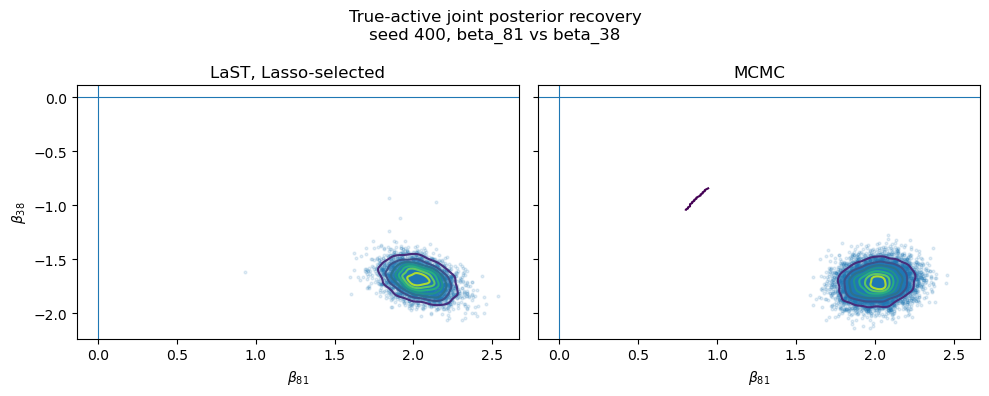

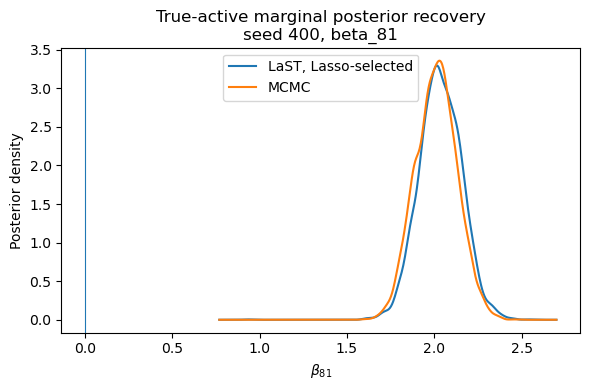

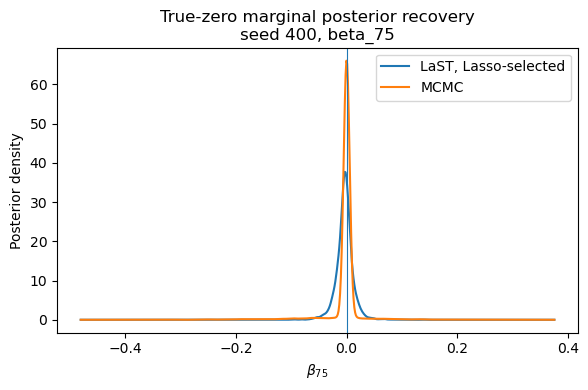

wrote figures to: e:\positron\NFlow\figures\local_lasso_recovery_check\seed_400


In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import torch

from Python.metric import sample_posterior_latents
from Python.utils import to_numpy


# -------------------------
# Basic setup
# -------------------------
seed_mcmc = 400
setting = "simple"

fig_dir = project_root / "figures" / "local_lasso_recovery_check" / f"seed_{seed_mcmc}"
fig_dir.mkdir(parents=True, exist_ok=True)

print("seed_mcmc:", seed_mcmc)
print("setting:", setting)
print("selected_ckpt:", out_lasso_test["selected_ckpt_id"])


# -------------------------
# Read LaST selected-checkpoint beta draws
# -------------------------
def get_selected_beta_soft_draws(flow_out, R=4000):
    model = flow_out["model"]
    ckpt_id = int(flow_out["selected_ckpt_id"])
    ckpt = flow_out["checkpoints"][ckpt_id]
    meta = ckpt["meta"]
    state = ckpt["state"]

    device = next(model.parameters()).device
    model.load_state_dict({k: v.to(device) for k, v in state.items()})
    model.generative_model.set_tau(float(meta["tau"]))
    model.eval()

    with torch.no_grad():
        draws = sample_posterior_latents(model, R=R)

    return to_numpy(draws["beta"]), meta


beta_last, selected_meta = get_selected_beta_soft_draws(
    out_lasso_test,
    R=schedule_cfg_test.diag_R_final,
)

print("selected epoch:", selected_meta["epoch"])
print("selected tau:", selected_meta["tau"])
print("lasso score:", selected_meta.get("lasso_recovery_score", None))
print("beta_last shape:", beta_last.shape)


# -------------------------
# Read same-seed MCMC beta draws
# -------------------------
def find_mcmc_beta_file(project_root, setting, seed):
    candidates = [
        project_root / "data" / "n160p100_mcmc_output" / setting / f"seed_{seed}" / "mcmc_beta_draws.csv.gz",
        project_root / "outputs_mcmc" / "n160p100_input" / setting / f"seed_{seed}" / "mcmc_beta_draws.csv.gz",
        project_root / "data" / "n160p100_mcmc_output" / "simple" / f"seed_{seed}" / "mcmc_beta_draws.csv.gz",
        project_root / "outputs_mcmc" / "n160p100_input" / "simple" / f"seed_{seed}" / "mcmc_beta_draws.csv.gz",
    ]

    for p in candidates:
        if p.exists():
            return p

    hits = list(project_root.rglob(f"seed_{seed}/mcmc_beta_draws.csv.gz"))
    if len(hits) == 0:
        raise FileNotFoundError(f"Cannot find mcmc_beta_draws.csv.gz for seed_{seed}")

    return hits[0]


mcmc_path = find_mcmc_beta_file(project_root, setting, seed_mcmc)
print("mcmc_path:", mcmc_path)

mcmc_df = pd.read_csv(mcmc_path)
if "draw_id" in mcmc_df.columns:
    mcmc_df = mcmc_df.drop(columns=["draw_id"])

beta_mcmc = mcmc_df.to_numpy(float)
print("beta_mcmc shape:", beta_mcmc.shape)


# -------------------------
# Choose variables for the first three figures
# -------------------------
beta_true_np = (
    beta1.detach().cpu().numpy()
    if hasattr(beta1, "detach")
    else np.asarray(beta1)
)

active_idx = np.where(np.abs(beta_true_np) > 1e-12)[0]
zero_idx = np.where(np.abs(beta_true_np) <= 1e-12)[0]

active_sorted = active_idx[np.argsort(-np.abs(beta_true_np[active_idx]))]

# Fig 1: top two true active variables
j_joint = int(active_sorted[0])
k_joint = int(active_sorted[1])

# Fig 2: strongest true active variable
j_active = int(active_sorted[0])

# Fig 3: choose a visually stable true-zero variable
# score = standardized mean mismatch + log-SD mismatch
zero_scores = []
for j in zero_idx:
    mu_l = beta_last[:, j].mean()
    mu_m = beta_mcmc[:, j].mean()
    sd_l = beta_last[:, j].std(ddof=1)
    sd_m = beta_mcmc[:, j].std(ddof=1)

    score = abs(mu_l - mu_m) / (sd_m + 1e-8) + abs(np.log((sd_l + 1e-8) / (sd_m + 1e-8)))
    zero_scores.append((score, int(j)))

j_zero = sorted(zero_scores)[0][1]

print("fig1 joint active:", j_joint, k_joint)
print("fig2 active marginal:", j_active)
print("fig3 zero marginal:", j_zero)


# -------------------------
# Plot helpers
# -------------------------
def kde_1d(x, grid):
    return gaussian_kde(x)(grid)


def plot_joint_density(beta_last, beta_mcmc, j, k, filename):
    x_last = beta_last[:, j]
    y_last = beta_last[:, k]

    x_mcmc = beta_mcmc[:, j]
    y_mcmc = beta_mcmc[:, k]

    x_all = np.concatenate([x_last, x_mcmc])
    y_all = np.concatenate([y_last, y_mcmc])

    x_pad = 0.08 * (x_all.max() - x_all.min() + 1e-8)
    y_pad = 0.08 * (y_all.max() - y_all.min() + 1e-8)

    x_grid = np.linspace(x_all.min() - x_pad, x_all.max() + x_pad, 140)
    y_grid = np.linspace(y_all.min() - y_pad, y_all.max() + y_pad, 140)

    Xg, Yg = np.meshgrid(x_grid, y_grid)
    grid_points = np.vstack([Xg.ravel(), Yg.ravel()])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

    for ax, x, y, label in [
        (axes[0], x_last, y_last, "LaST, Lasso-selected"),
        (axes[1], x_mcmc, y_mcmc, "MCMC"),
    ]:
        vals = np.vstack([x, y])
        Z = gaussian_kde(vals)(grid_points).reshape(Xg.shape)

        ax.contour(Xg, Yg, Z, levels=7)
        ax.scatter(x, y, s=4, alpha=0.12)
        ax.axhline(0, linewidth=0.8)
        ax.axvline(0, linewidth=0.8)
        ax.set_title(label)
        ax.set_xlabel(rf"$\beta_{{{j}}}$")

    axes[0].set_ylabel(rf"$\beta_{{{k}}}$")

    fig.suptitle(
        "True-active joint posterior recovery\n"
        f"seed {seed_mcmc}, beta_{j} vs beta_{k}"
    )
    fig.tight_layout()

    fig.savefig(fig_dir / f"{filename}.png", dpi=300)
    fig.savefig(fig_dir / f"{filename}.pdf")
    plt.show()


def plot_marginal_density(beta_last, beta_mcmc, j, title, filename):
    x_last = beta_last[:, j]
    x_mcmc = beta_mcmc[:, j]

    x_all = np.concatenate([x_last, x_mcmc])
    pad = 0.10 * (x_all.max() - x_all.min() + 1e-8)
    grid = np.linspace(x_all.min() - pad, x_all.max() + pad, 600)

    d_last = kde_1d(x_last, grid)
    d_mcmc = kde_1d(x_mcmc, grid)

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(grid, d_last, label="LaST, Lasso-selected")
    ax.plot(grid, d_mcmc, label="MCMC")
    ax.axvline(0, linewidth=0.8)

    ax.set_xlabel(rf"$\beta_{{{j}}}$")
    ax.set_ylabel("Posterior density")
    ax.set_title(title + f"\nseed {seed_mcmc}, beta_{j}")
    ax.legend()

    fig.tight_layout()

    fig.savefig(fig_dir / f"{filename}.png", dpi=300)
    fig.savefig(fig_dir / f"{filename}.pdf")
    plt.show()


# -------------------------
# Make the first three figures
# -------------------------
plot_joint_density(
    beta_last=beta_last,
    beta_mcmc=beta_mcmc,
    j=j_joint,
    k=k_joint,
    filename="fig1_true_active_joint_density",
)

plot_marginal_density(
    beta_last=beta_last,
    beta_mcmc=beta_mcmc,
    j=j_active,
    title="True-active marginal posterior recovery",
    filename="fig2_true_active_marginal_density",
)

plot_marginal_density(
    beta_last=beta_last,
    beta_mcmc=beta_mcmc,
    j=j_zero,
    title="True-zero marginal posterior recovery",
    filename="fig3_true_zero_marginal_density",
)

print("wrote figures to:", fig_dir)